# Experiments

## 1. Datasets used

The tests were performed using 3 distinct datasets, differing in size, quantity, and issues. The dataset sources are:

- dummy: Created by author
- car_price: https://www.kaggle.com/datasets/milanvaddoriya/old-car-price-prediction
- movies: https://www.kaggle.com/datasets/pendulun/movie-ratings (Created by author)

In [1]:
import pandas as pd

In [2]:
dummy_dataset = pd.read_csv("../data/test_data.csv")
car_dataset =  pd.read_csv("../data/car_price.csv")
movies_dataset =  pd.read_csv("../data/movieRatingsMid2026.csv")

### 1.1 Dummy dataset

In [3]:
dummy_dataset.shape, dummy_dataset.dtypes

((7, 7),
 Loja                 str
 data_abertura        str
 classe               str
 metragem         float64
 faturamento        int64
 qt_mesas           int64
 especial             str
 dtype: object)

In [4]:
dummy_dataset

,Loja,data_abertura,classe,metragem,faturamento,qt_mesas,especial
0,'Loja A','20/01/2023','Popular',50.0,1000000,5,'Sim'
1,'Loja B','07/04/2020','Premium',62.0,1500000,7,'Sim'
2,'Loja C','01/01/2023','Mista',43.0,1200000,6,'Não'
3,'Loja D','01/01/2024','Genérica',45.0,900000,4,'Não'
4,'Loja E','07/05/2024','Mista',45.0,1000000,4,NaN
5,'Loja F','18/04/2024','Mista',50.0,1050000,4,NaN
6,'Loja G','10/04/2024','Premium',NaN,1150000,4,'Sim'


The *dummy_dataset* is quite small, with only 7 rows and 7 columns. Some of the initial problems identified are:

- The *data_abertura* (opening_date) column is in string format when it should be in *datetime* format.
- The *classe* (class) column is a categorical column but is not in a numeric format that can be used by a regression model.
- The *metragem* (area in meters) column has a null value.
- The *especial* (special) column has null values and is also not in numeric format, for example, binary.

### 1.2 Movies dataset

In [5]:
movies_dataset.shape, movies_dataset.dtypes, movies_dataset.isna().sum()

((103, 18),
 ID                       int64
 Movie                      str
 Watch Date                 str
 Year                     int64
 Type 1                     str
 Type 2                     str
 Animation                int64
 Origin Country             str
 Friend Who chose it    float64
 Did Friend 5 sleep     float64
 Duration (minutes)       int64
 Friend 2 score         float64
 Friend 5 score         float64
 Friend 7 score         float64
 Friend 8 score         float64
 Mean score                 str
 IMDB score                 str
 IMDB-Mean                  str
 dtype: object,
 ID                      0
 Movie                   0
 Watch Date              0
 Year                    0
 Type 1                  0
 Type 2                  1
 Animation               0
 Origin Country          0
 Friend Who chose it    15
 Did Friend 5 sleep     10
 Duration (minutes)      0
 Friend 2 score          4
 Friend 5 score          7
 Friend 7 score          9
 Friend 8 score   

In [6]:
movies_dataset.head()

,ID,Movie,Watch Date,Year,Type 1,Type 2,Animation,Origin Country,Friend Who chose it,Did Friend 5 sleep,Duration (minutes),Friend 2 score,Friend 5 score,Friend 7 score,Friend 8 score,Mean score,IMDB score,IMDB-Mean
0,1,Elite Squad,09/09/2021,2007,Action,Crime,0,Brazil,3.0,1.0,115,8.0,9.0,9.0,9.0,"8,75",8,"-0,75"
1,2,The Forever Purge,16/09/2021,2021,Action,Horror,0,USA,1.0,0.0,104,2.0,2.0,2.0,2.0,"2,00","5,4","3,40"
2,3,Forrest Gump,23/09/2021,1994,Drama,Romance,0,USA,2.0,0.0,142,10.0,9.0,9.0,10.0,"9,50","8,8","-0,70"
3,4,The Orphanage,30/09/2021,2007,Horror,Thriller,0,Spain,5.0,0.0,105,8.0,8.0,7.0,7.0,"7,50","7,4","-0,10"
4,5,Rubber,07/10/2021,2010,Horror,Comedy,0,France,6.0,0.0,85,4.0,4.0,4.0,10.0,"5,50","5,7","0,20"


The movie rating dataset has 103 rows and 18 columns. Some of its issues are:

- The *Watch Date* column is in *string* format when it could be in *datetime* format.
- The *Type 1*, *Type 2*, and *Origin Country* columns are categorical and therefore some type of *encoding* could be applied to their values via *one-hot* or mappings within the columns themselves.
- The *Type 2* column has a null value.
- The *Mean score*, *IMDB score*, and *IMDB-Mean* columns are formatted in such a way that they're considered *string* instead of numeric.

### 1.3 Car prices dataset

In [7]:
car_dataset.shape, car_dataset.dtypes, car_dataset.isna().sum()

((5512, 10),
 Unnamed: 0             int64
 car_name                 str
 car_prices_in_rupee      str
 kms_driven               str
 fuel_type                str
 transmission             str
 ownership                str
 manufacture            int64
 engine                   str
 Seats                    str
 dtype: object,
 Unnamed: 0             0
 car_name               0
 car_prices_in_rupee    0
 kms_driven             0
 fuel_type              0
 transmission           0
 ownership              0
 manufacture            0
 engine                 0
 Seats                  0
 dtype: int64)

In [8]:
car_dataset.head()

,Unnamed: 0,car_name,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,manufacture,engine,Seats
0,0,Jeep Compass 2.0 Longitude Option BSIV,10.03 Lakh,"86,226 kms",Diesel,Manual,1st Owner,2017,1956 cc,5 Seats
1,1,Renault Duster RXZ Turbo CVT,12.83 Lakh,"13,248 kms",Petrol,Automatic,1st Owner,2021,1330 cc,5 Seats
2,2,Toyota Camry 2.5 G,16.40 Lakh,"60,343 kms",Petrol,Automatic,1st Owner,2016,2494 cc,5 Seats
3,3,Honda Jazz VX CVT,7.77 Lakh,"26,696 kms",Petrol,Automatic,1st Owner,2018,1199 cc,5 Seats
4,4,Volkswagen Polo 1.2 MPI Highline,5.15 Lakh,"69,414 kms",Petrol,Manual,1st Owner,2016,1199 cc,5 Seats


The car price dataset has 5512 rows and 10 columns. Some of its issues are:

- The columns *fuel_type*, *transmission*, and *ownership* are categorical and would benefit from applying *encoding* to their values.
- The columns *car_prices_in_rupee*, *kms_driven*, *engine*, and *Seats* have suffixes that make them *string* instead of numeric. In particular, the column *car_prices_in_rupee* has two different suffixes: *Lakh* and *Crore*. The first is a unit of measurement for every 100,000 rupees, the second indicates 10 million rupees.

Based on these initial problem analyses, a data-readiness agent is expected to be able to handle all of them, providing a suitable foundation for subsequent analyses and applications of machine learning techniques.

## 2. Expected Corrections per Dataset

Each test dataset has its own set of improvements that the agent is expected to make. These improvements were defined based on my experience as a data scientist for later use in analyses and application of machine learning models. The evaluation conditions are divided into:
1) Data types
2) Presence of null data
3) Column cardinality
4) Numerical range
5) Actions recommended by the evaluation agent
6) Severity of problems found in the column

This section details the expected conditions for each dataset at the end of its processing by the agent.

2.1 Expectations in the Assessment Agent's Analysis

Below are the expected severity levels of problems encountered and recommended actions, categorized by column in the database, as determined by the assessment agent:
| Dataset      | Column              | Severity    | Actions                                      |
|-----------|---------------------|---------------|--------------------------------------------|
| dummy     | metragem            |   Mean       | Impute missing values                      |
| dummy     | classe              | Low         | Apply *encoding*                         |
| dummy     | especial            |  Mean        | Impute missing values and apply *encoding* |
| dummy     | data_abertura       |  Mean        | Convert to datetime                   |
| dummy     | faturamento         | No Problems |                                            |
| dummy     | qt_mesas            | No Problems |                                            |
| dummy     | Loja                | No Problems |                                            |
| movies    | ID                  | Low         | Drop column                             |
| movies    | Movie               | No Problems |                                            |
| movies    | Watch Date          |  Mean        | Convert to datetime               |
| movies    | Year                | Low         | Create derived 'age' column           |
| movies    | Type 1              |  Mean        | Apply *encoding*                |
| movies    | Type 2              |  Mean        | Impute missing values and apply *encoding* |
| movies    | Animation           | No Problems |                                            |
| movies    | Origin Country      |   Mean       | Apply *encoding*                         |
| movies    | Mean score          | High          |  Convert to numeric              |
| movies    | IMDB score          | High          |  Convert to numeric              |
| movies    | IMDB-Mean           | High          |  Convert to numeric              |
| movies    | Did Friend 5 sleep  |   Mean       |                                            |
| movies    | Duration (minutes)  | No Problems |                                            |
| movies    | Friend 2 score      | Low         |                                            |
| movies    | Friend 5 score      | Low         |                                            |
| movies    | Friend 7 score      | Low         |                                            |
| movies    | Friend 8 score      | Low         |                                            |
| car_price | Unnamed: 0          | Low         | Drop column                             |
| car_price | car_name            | No Problems |                                            |
| car_price | car_prices_in_rupee | High          |  Convert to numeric              |
| car_price | kms_driven          | High          |  Convert to numeric              |
| car_price | fuel_type           |  Mean        | Apply *encoding*                         |
| car_price | transmission        |  Mean        | Apply *encoding*                         |
| car_price | ownership           |  Mean        | Apply *encoding*                         |
| car_price | manufacture         | No Problems |                                            |
| car_price | engine              | High          |  Convert to numeric              |
| car_price | Seats               | High          |  Convert to numeric              |

### 2.2 Expectations after applying the transformation agent

The following are the expectations regarding the state of the database columns after applying the transformations:

| Dataset      | Column              | Type      | Don't have NaNs | Cardinality |  Numeric range   |
|-----------|---------------------|-----------|---------------|---------------|-------------------|
| dummy     | metragem            |  Numeric | Yes           |               | [43, 62]          |
| dummy     | classe              | Numeric  |               | 4             |                   |
| dummy     | especial            | Numeric  | Yes           | 3             |                   |
| dummy     | data_abertura       | datetime  |               |               |                   |
| dummy     | faturamento         | Numeric  |               |               |                   |
| dummy     | qt_mesas            | Numeric  |               |               | [4, 7]            |
| dummy     | Loja                | string    |               |               |                   |
| movies    | ID                  |           |               |               |                   |
| movies    | Movie               | string    |               |               |                   |
| movies    | Watch Date          | datetime  |               |               |                   |
| movies    | Year                | Numeric  | Yes           |               | [1975, 2026]      |
| movies    | Type 1              | Numeric  | Yes           |               |                   |
| movies    | Type 2              | Numeric  | Yes           |               |                   |
| movies    | Animation           | Numeric  | Yes           |               | [0, 1]            |
| movies    | Origin Country      | Numeric  | Yes           | 11            |                   |
| movies    | Mean score          | Numeric  | Yes           |               | [0, 10]           |
| movies    | IMDB score          | Numeric  | Yes           |               | [0, 10]           |
| movies    | IMDB-Mean           | Numeric  | Yes           |               |                   |
| movies    | Friend who chose it | Numeric  | Yes           |               | [1, 8]            |
| movies    | Did Friend 5 sleep  | Numeric  | Yes           |               |                   |
| movies    | Duration (minutes)  | Numeric  | Yes           |               | [66, 176]         |
| movies    | Friend 2 score      | Numeric  | Yes           |               |                   |
| movies    | Friend 5 score      | Numeric  | Yes           |               |                   |
| movies    | Friend 7 score      | Numeric  | Yes           |               |                   |
| movies    | Friend 8 score      | Numeric  | Yes           |               |                   |
| car_price | Unnamed: 0          | Numeric  |               |               |                   |
| car_price | car_name            | string    |               |               |                   |
| car_price | car_prices_in_rupee | Numeric  | Yes           |               | [35000, 19200000] |
| car_price | kms_driven          | Numeric  | Yes           |               | [250, 560000]     |
| car_price | fuel_type           | Numeric  | Yes           | 5             |                   |
| car_price | transmission        | Numeric  | Yes           | 2             |                   |
| car_price | ownership           | Numeric  | Yes           | 6             |                   |
| car_price | manufacture         | Numeric  | Yes           |               |                   |
| car_price | engine              | Numeric  | Yes           |               |                   |
| car_price | Seats               | Numeric  | Yes           |               | [2, 8]            |

## 3. Experimental Configurations

To evaluate the agent, various combinations of models were used in the evaluation and transformation stages of the original dataset. The configurations tested were:

| ID |   Evaluation Agent Model |  Transformation Agent Model |
|----|---------------------------|------------------------------|
| 1  | gpt-4.1-nano              | gpt-4.1-nano                 |
| 2  | gpt-4o-mini               | gpt-4.1-nano                 |
| 3  | gpt-4o-mini               | gpt-4o-mini                  |
| 4  | gpt-5-mini                | gpt-4o-mini                  |
| 5  | gpt-5-mini                | gpt-5-mini                   |
| 6  | gpt-5-nano                | gpt-5-mini                   |
| 7  | gpt-5-nano                | gpt-5-nano                   |
| 8  | gpt-4.1-nano              | gpt-5-nano                   |

This configuration allows for the evaluation of the use of distinct models with different capabilities working together or exclusively. For example, configurations 1, 3, 4, and 7 are exclusively formed by only one model. The others combine models with different capabilities (and costs).

For each configuration, 4 runs were executed to evaluate the variability of the results. This low number of runs was defined to avoid excessive costs at the end of the experiments. In another context, we could increase the number of runs per configuration to improve the accuracy of the results.

Since each model is used twice in the evaluation agent and twice in the transformation agent, there are 8 runs per model/agent combination. Furthermore, since there are 3 datasets, the total number of runs was $3 × 8 × 4 = 96$.

Maximum number of iterations to be performed by the agents was also defined to limit processing and avoid endless loops that could generate unwanted costs. The following table shows the values ​​of these parameters.

| Dataset   | Eval max its | Eval max supersteps | Transformation max its | Transformation max supersteps |
|-----------|--------------|---------------------|------------------------|-------------------------------|
| dummy     | 5            | 45                  | 15                     | 45                            |
| car_price | 15           | 105                 | 35                     | 105                           |
| movies    | 20           | 80                  | 35                     | 105                           |

The transformation agent having more iterations available than the evaluation agent is based on the understanding that a goal defined in the evaluation stage may require more than one action in the transformation stage to be completed. For example, to transform a string column into a numeric one, it may be necessary to remove suffixes from its values ​​before performing the conversion.

## 4. Results

This section analyzes the results obtained.

### 4.1 Results for the evaluation step

This subsection analyzes the results obtained regarding the expectations for the dataset evaluation agent.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
def load_eval_results() -> dict[str, pd.DataFrame]:
    RESULTS_BASE_DIR_PATH = "../src_data_readyness_agent/testing/test_results/"
    results_map = [
        {'dataset':'dummy', 'path':RESULTS_BASE_DIR_PATH + "eval_agent_dummy_data.csv"},
        {'dataset':'movie_ratings', 'path':RESULTS_BASE_DIR_PATH + "eval_agent_movie_ratings_data.csv"},
        {'dataset':'car_prices', 'path':RESULTS_BASE_DIR_PATH + "eval_agent_car_price_data.csv"}
    ]
    result = dict()
    for dataset_result in results_map:
        curr_result = pd.read_csv(dataset_result['path'])
        result[dataset_result['dataset']] = curr_result 
    return result

In [11]:
eval_results = load_eval_results()
for dataset_name, df in eval_results.items():
    print(dataset_name, "results shape:", df.shape)

dummy results shape: (32, 23)
movie_ratings results shape: (32, 38)
car_prices results shape: (32, 29)


According to the expectations outlined in section 3 and the number of runs, each dataset has 32 associated runs and a different number of columns containing boolean values. Each column represents something to be verified. In addition, there are also columns for token usage statistics and the associated cost.

In [12]:
eval_results['dummy'].head().T

,0,1,2,3,4
metragem_expected_action_has_fill_missing_values,True,True,True,True,True
classe_expected_action_has_encode_categorical,False,False,False,False,False
especial_expected_action_has_fill_missing_values,True,True,False,False,False
especial_expected_action_has_encode_categorical,True,False,False,False,False
data_abertura_expected_action_has_convert_dtype,False,False,False,False,False
metragem_severity_is_medium,True,False,True,True,False
classe_severity_is_low,False,False,False,False,False
especial_severity_is_medium,True,True,False,True,True
data_abertura_severity_is_medium,False,False,False,False,False
faturamento_severity_is_no problem,False,False,False,False,False


In [13]:
def get_general_results(all_results:dict[str, pd.DataFrame]):
    results = pd.DataFrame()
    models = list()
    avg_accs = list()
    datasets = list()
    total_cost = list()
    run_ids = list()
    for dataset in all_results.keys():
        target_bool_cols = all_results[dataset].select_dtypes('boolean').columns.tolist()
        
        for model, rows in all_results[dataset].groupby('model'):
            avg_accs.extend(rows[target_bool_cols].mean(axis=1).round(2).tolist())
            models.extend([model] * len(rows))
            datasets.extend([dataset] * len(rows))
            total_cost.extend(rows['total_cost'].tolist())
            run_ids.extend(rows['run_id'].tolist())
        
    results['avg_acc'] = avg_accs
    results['model'] = models
    results['dataset'] = datasets
    results['total_cost'] = total_cost
    results['run_id'] = run_ids
    return results

In [14]:
general_eval_results = get_general_results(eval_results)

In [15]:
def plot_general_results(results, suptitle, title):
    fig, axs = plt.subplots(ncols=2, figsize=(12, 5))
    axs = axs.flatten()
    
    results['total_cost_per_acc'] = results['total_cost'] / results['avg_acc']
    
    sns.pointplot(data=results, y='avg_acc', x='model', hue='dataset', errorbar=("pi", 50), alpha=0.65, ax=axs[0])
    axs[0].legend(title='Dataset')
    axs[0].set_ylabel("Average rate of expectations met per run")
    
    sns.pointplot(data=results, y='total_cost_per_acc', x='model', hue='dataset', errorbar=("pi", 50), alpha=0.65, ax=axs[1])
    axs[1].set_ylabel("Cost per performance ($) per run")
    
    fig.suptitle(suptitle)
    fig.text(0.5, 0.93, title, ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    plt.close()

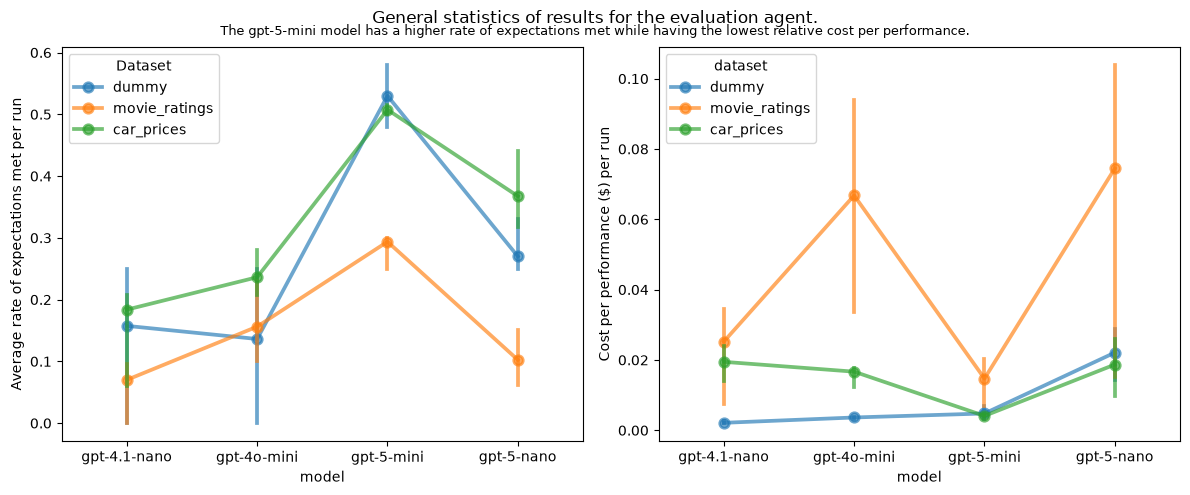

In [16]:
suptitle = "General statistics of results for the evaluation agent."
title = "The gpt-5-mini model has a higher rate of expectations met while having the lowest relative cost per performance."
plot_general_results(general_eval_results, suptitle=suptitle,title=title)

The results above show that the *gpt-5-mini* model tends to better meet the expectations established for the dataset evaluation step, in addition to having the best overall cost-benefit ratio according to the second graph. In contrast, the *gpt-5-nano* model appears to have greater performance variability while incurring relatively high costs.

The graphs above also indicate the relative difficulty of the datasets, with the models tending to achieve better evaluation results in *car_prices*, followed by *dummy*, and then *movie_ratings*.

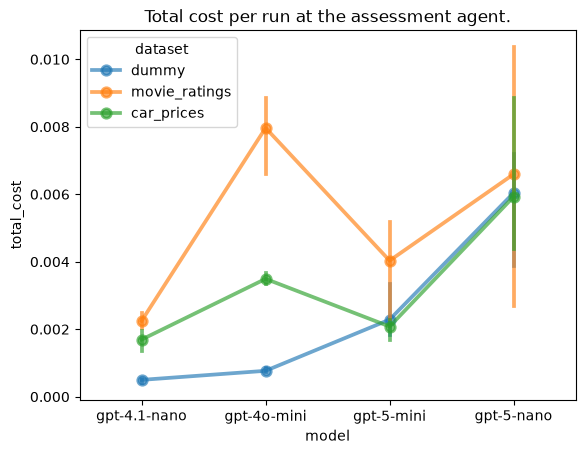

In [17]:
sns.pointplot(data=general_eval_results, y='total_cost', x='model', hue='dataset', errorbar=("pi", 50), alpha=0.65)
plt.title("Total cost per run at the assessment agent.")
plt.show()
plt.tight_layout()
plt.close()

The graph above shows that, despite having the best overall results, *gpt-5-mini* does not have the lowest total costs. However, its costs are indeed close to the lowest costs observed.

## 4.2 Results for the Transformation Step

This section analyzes the results obtained by verifying the expectations achieved after the transformation stage and the tools used.

In [18]:
def load_transform_results() -> dict[str, pd.DataFrame]:
    RESULTS_BASE_DIR_PATH = "../src_data_readyness_agent/testing/test_results/"
    results_map = [
        {'dataset':'dummy', 'path':RESULTS_BASE_DIR_PATH + "transformation_agent_dummy_data.csv"},
        {'dataset':'movie_ratings', 'path':RESULTS_BASE_DIR_PATH + "transformation_agent_movie_ratings_data.csv"},
        {'dataset':'car_prices', 'path':RESULTS_BASE_DIR_PATH + "transformation_agent_car_price_data.csv"}
    ]
    result = dict()
    for dataset_result in results_map:
        curr_result = pd.read_csv(dataset_result['path'])
        result[dataset_result['dataset']] = curr_result 
    return result

In [19]:
transformation_results = load_transform_results()
for dataset_name, df in transformation_results.items():
    print(dataset_name, "results shape:", df.shape)

dummy results shape: (32, 24)
movie_ratings results shape: (32, 52)
car_prices results shape: (32, 35)


In [20]:
transformation_results['dummy'].head().T

,0,1,2,3,4
metragem_dtype_is_numeric,True,True,True,True,True
classe_dtype_is_numeric,False,False,False,False,False
especial_dtype_is_numeric,False,False,True,True,False
data_abertura_dtype_is_datetime,False,False,False,False,False
faturamento_dtype_is_numeric,True,True,True,True,True
qt_mesas_dtype_is_numeric,True,True,True,True,True
Loja_dtype_is_string,True,True,True,True,True
metragem_doesnt_has_nulls,True,True,True,True,True
especial_doesnt_has_nulls,True,False,True,True,True
especial_cardinality_is_3,False,False,False,False,False


In [21]:
general_transformation_results = get_general_results(transformation_results)

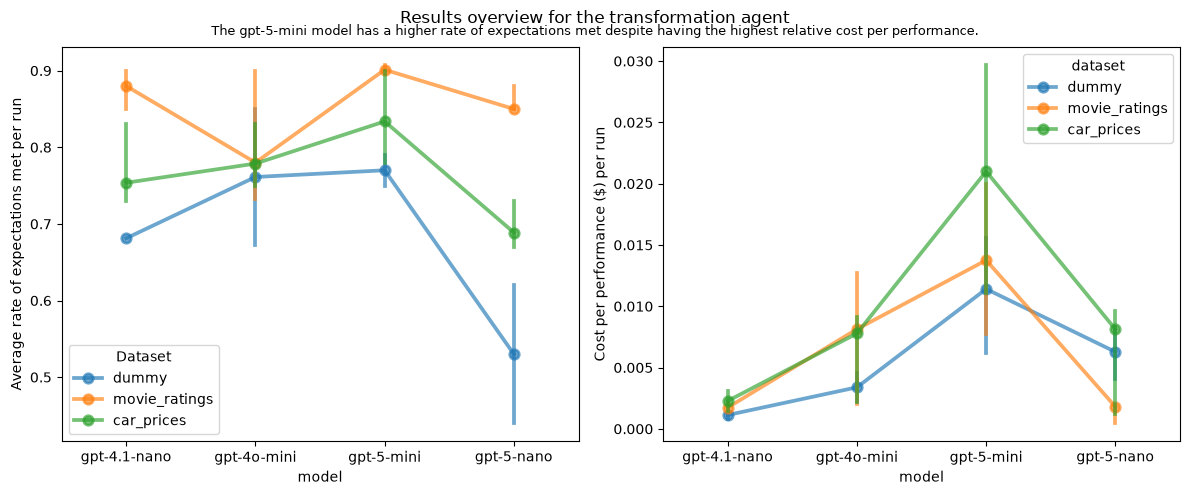

In [22]:
suptitle = "Results overview for the transformation agent"
title = "The gpt-5-mini model has a higher rate of expectations met despite having the highest relative cost per performance."
plot_general_results(general_transformation_results, suptitle=suptitle,title=title)

The graphs above show that the transformation task appears to be easier overall when compared to the evaluation task, according to the high rates of expectations achieved. This notion may be due to several issues.

First, the models had more iterations allowed in the transformation stage than in the evaluation stage, as shown in section 3. Thus, by relatively limiting the number of evaluations, the chances of achieving an expectation in that stage are also limited. Equivalently, the more iterations allowed in the transformation stage, the greater the agent's chances of achieving expectations.

Second, the evaluation stage can be characterized as an exploratory phase, while the transformation stage is characterized as a phase of following more explicit instructions. This is because, while the evaluation agent did not receive any specific instructions on what to check, the transformation agent received instructions produced by the evaluation agent itself. Thus, having more direction, it is fair to think that the transformation phase is better able to meet expectations.

Regarding the relative difficulty of the datasets, the *movie_ratings* dataset is now the one where the models performed best. Meanwhile, the *dummy* and *car_prices* datasets swapped relative difficulty positions, with the *dummy* being more difficult.

Regarding model performance, *gpt-5-mini* again appears to achieve the best performance among the models; however, this time it has the highest relative costs.

Therefore, the following question arises: **To accomplish the task as a whole, is it sufficient to have a good model in the evaluation phase, or is it necessary for both agents to have models with better capabilities?**

To answer this question, let's compare the results of fixing the model in the evaluation phase and changing the transformation model.

In [23]:
target_cols = ['avg_acc', 'total_cost', 'model', 'run_id', 'dataset']
merged_results = general_eval_results[target_cols].merge(general_transformation_results[target_cols], 
                                                         on =['run_id', 'dataset'], 
                                                         suffixes=("_eval", "_transform"))
merged_results['config_name'] = merged_results['model_eval'] + "/" + merged_results['model_transform']
merged_results.head()

,avg_acc_eval,total_cost_eval,model_eval,run_id,dataset,avg_acc_transform,total_cost_transform,model_transform,config_name
0,0.42,0.000256,gpt-4.1-nano,1,dummy,0.69,0.001450,gpt-4.1-nano,gpt-4.1-nano/gpt-4.1-nano
1,0.25,0.000509,gpt-4.1-nano,2,dummy,0.54,0.000793,gpt-4.1-nano,gpt-4.1-nano/gpt-4.1-nano
2,0.17,0.000433,gpt-4.1-nano,3,dummy,0.69,0.000828,gpt-4.1-nano,gpt-4.1-nano/gpt-4.1-nano
3,0.25,0.000523,gpt-4.1-nano,4,dummy,0.77,0.000562,gpt-4.1-nano,gpt-4.1-nano/gpt-4.1-nano
4,0.17,0.000572,gpt-4.1-nano,29,dummy,0.77,0.001800,gpt-5-nano,gpt-4.1-nano/gpt-5-nano


In [24]:
def plot_config_results(results:pd.DataFrame, suptitle:str, title:str, before_col:str, after_col:str, target_col_name:str, highlight_configs:list[str]=None):
    merged_cp = pd.DataFrame()
    moments = list()
    target_values = list()
    datasets = list()
    config_names = list()
    for idx, row in results.iterrows():
        moments.extend(['evaluation', 'transformation'])
        datasets.extend([row['dataset']]*2)
        target_values.extend([row[before_col], row[after_col]])
        config_names.extend([row['config_name']] * 2)
    
    merged_cp['moment'] = moments
    merged_cp['dataset'] = datasets
    merged_cp[target_col_name] = target_values
    merged_cp['config_name'] = config_names

    cmap = plt.get_cmap("tab10")

    base_configs = sorted(list(set(config_names)))

    color_map = {
        config: cmap(i)
        for i, config in enumerate(base_configs)
    }
    if highlight_configs is None:
        highlight_configs = base_configs

    blank_color = 'silver'
    actual_colors = {
        config: color_map[config] if config in highlight_configs else blank_color
        for config in color_map
    }
    hue_order = [config for config in color_map if config not in highlight_configs] + list(highlight_configs)
    fig = sns.catplot(data=merged_cp, col='dataset', hue='config_name', x='moment', y=target_col_name, kind='point',
                palette=actual_colors, alpha=0.8, hue_order=hue_order)
    fig.figure.set_size_inches(12, 5)
    fig.legend.set_title("Eval model/Transformation model")
    fig.legend.set_bbox_to_anchor((1.02, 0.5))
    fig.legend.set_loc("center left")
    fig.figure.suptitle(suptitle, fontsize=14, y=0.98)
    fig.figure.text(0.5, 0.9, title, ha='center', fontsize=10)
    fig.figure.subplots_adjust(top=0.8)
    plt.tight_layout()
    plt.show()
    plt.close()

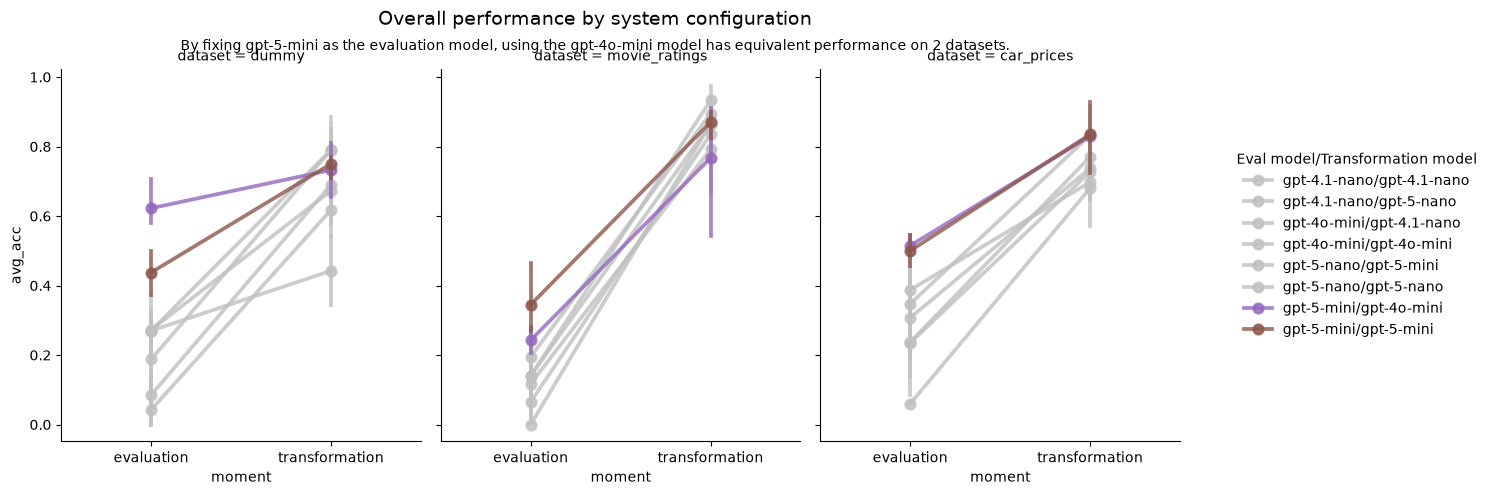

In [25]:
suptitle = "Overall performance by system configuration"
title = "By fixing gpt-5-mini as the evaluation model, using the gpt-4o-mini model has equivalent performance on 2 datasets."
plot_config_results(merged_results, suptitle, title, before_col='avg_acc_eval', after_col='avg_acc_transform', 
                    target_col_name='avg_acc', highlight_configs=['gpt-5-mini/gpt-4o-mini', 'gpt-5-mini/gpt-5-mini'])

The graphs above show that, by fixing the *gpt-5-mini* model as the evaluation agent model (since it achieved the best overall performance), using the *gpt-4o-mini* model as the transformation agent model achieved equivalent results in 2 of the 3 datasets.

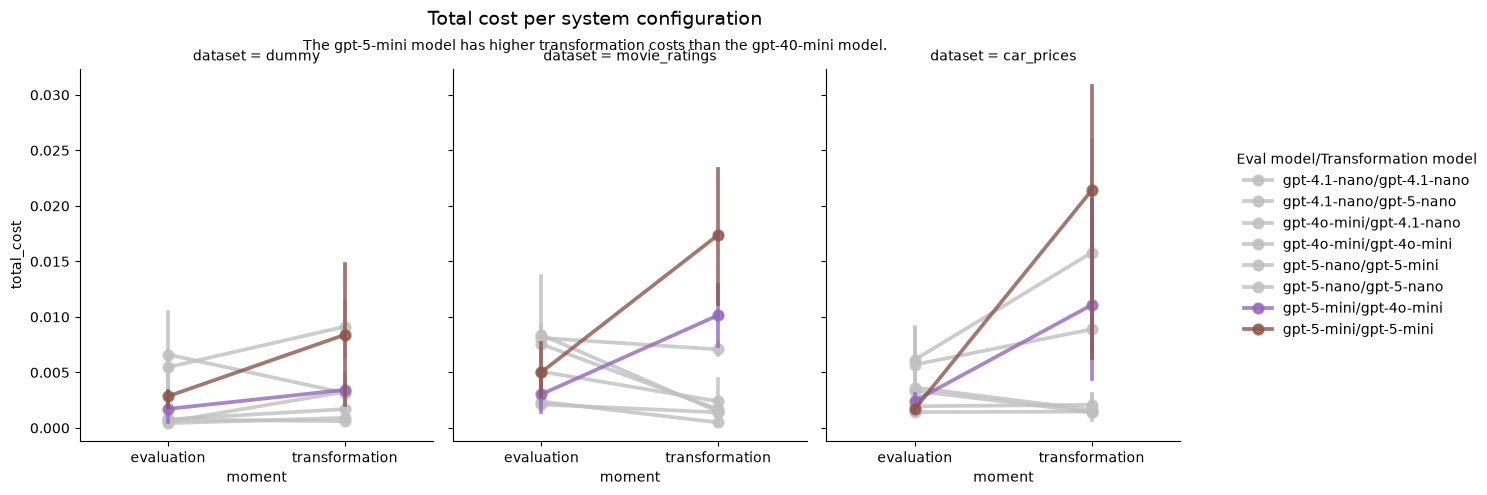

In [26]:
suptitle = "Total cost per system configuration"
title = "The gpt-5-mini model has higher transformation costs than the gpt-40-mini model."
plot_config_results(merged_results, suptitle, title, before_col='total_cost_eval', after_col='total_cost_transform', 
                    target_col_name='total_cost',highlight_configs=['gpt-5-mini/gpt-4o-mini', 'gpt-5-mini/gpt-5-mini'])

The graphs above show that, when comparing the costs of using different models in the transformation agent, the *gpt-4o-mini* model tends to be less expensive than the *gpt-5-mini* model.

Therefore, it can be inferred that the configuration of *gpt-5-mini* as the evaluation agent and *gpt-4o-mini* as the transformation agent is the best found. This can be justified by the results found in section 4.1, where *gpt-5-mini* best met expectations and had the lowest relative cost to performance, and by the fact that, when using *gpt-4o-mini* in the transformation model, which is a faster and cheaper model than *gpt-5-mini*, equivalent performances were observed in 2 of the 3 datasets analyzed. Thus, this combination hits a sweet spot between cost and benefit.

Finally, to answer the question posed earlier, **it can be said that a model that can clearly and completely indicate the next steps in the analysis phase helps a less capable model to perform sufficiently well in the transformation phase.** Therefore, one strategy would be to use a more capable model in the evaluation phase and a cheaper one in the transformation phase.

## 4.3 Ablation - Analysis of Tools Used

In addition to the expectations per step, the history of tool calls in the transformation step was also saved. This history consists of the tool name, the arguments used, and whether the call was successful or not.

This section analyzes this history.

In [27]:
def load_tool_usage_history() -> dict[str, pd.DataFrame]:
    RESULTS_BASE_DIR_PATH = "../src_data_readyness_agent/testing/test_results/"
    results_map = [
        {'dataset':'dummy', 'path':RESULTS_BASE_DIR_PATH + "transformation_agent_tool_usage_dummy_data.csv"},
        {'dataset':'movie_ratings', 'path':RESULTS_BASE_DIR_PATH + "transformation_agent_tool_usage_movie_ratings_data.csv"},
        {'dataset':'car_prices', 'path':RESULTS_BASE_DIR_PATH + "transformation_agent_tool_usage_car_price_data.csv"}
    ]
    result = dict()
    for dataset_result in results_map:
        curr_result = pd.read_csv(dataset_result['path'])
        result[dataset_result['dataset']] = curr_result 
    return result

In [28]:
tool_usage_history = load_tool_usage_history()

#### Question 1: Is the performance of the transformation agent positively related to the increased use of tools?

According to the expectations defined in the transformation phase, it is expected that the more tools used, the greater the chances of achieving those expectations. Let's see if this is true.

In [29]:
def get_tool_usage_results_by_run(run_base_results:pd.DataFrame, tool_usage_hist:dict[str, pd.DataFrame]) -> pd.DataFrame:
    partial_results = list()
    for dataset in run_base_results.dataset.unique():
        tool_usage_by_run = tool_usage_hist[dataset].groupby('run_id').size().reset_index().rename(columns={0:'Tool count'})
        target_cols = ['run_id', 'avg_acc_transform', 'dataset', 'model_transform', 'config_name']
        curr_result = run_base_results[run_base_results.dataset == dataset][target_cols].merge(tool_usage_by_run, on ='run_id')
        
        tool_sucess_by_run = tool_usage_hist[dataset].groupby('run_id')['sucess'].sum().reset_index()
        curr_result = curr_result.merge(tool_sucess_by_run, on ='run_id')
        
        partial_results.append(curr_result)
    return pd.concat(partial_results)

In [30]:
tool_usage_results = get_tool_usage_results_by_run(merged_results, tool_usage_history)
tool_usage_results.head()

,run_id,avg_acc_transform,dataset,model_transform,config_name,Tool count,sucess
0,1,0.69,dummy,gpt-4.1-nano,gpt-4.1-nano/gpt-4.1-nano,14,14
1,2,0.54,dummy,gpt-4.1-nano,gpt-4.1-nano/gpt-4.1-nano,8,8
2,3,0.69,dummy,gpt-4.1-nano,gpt-4.1-nano/gpt-4.1-nano,8,8
3,4,0.77,dummy,gpt-4.1-nano,gpt-4.1-nano/gpt-4.1-nano,5,5
4,29,0.77,dummy,gpt-5-nano,gpt-4.1-nano/gpt-5-nano,3,2


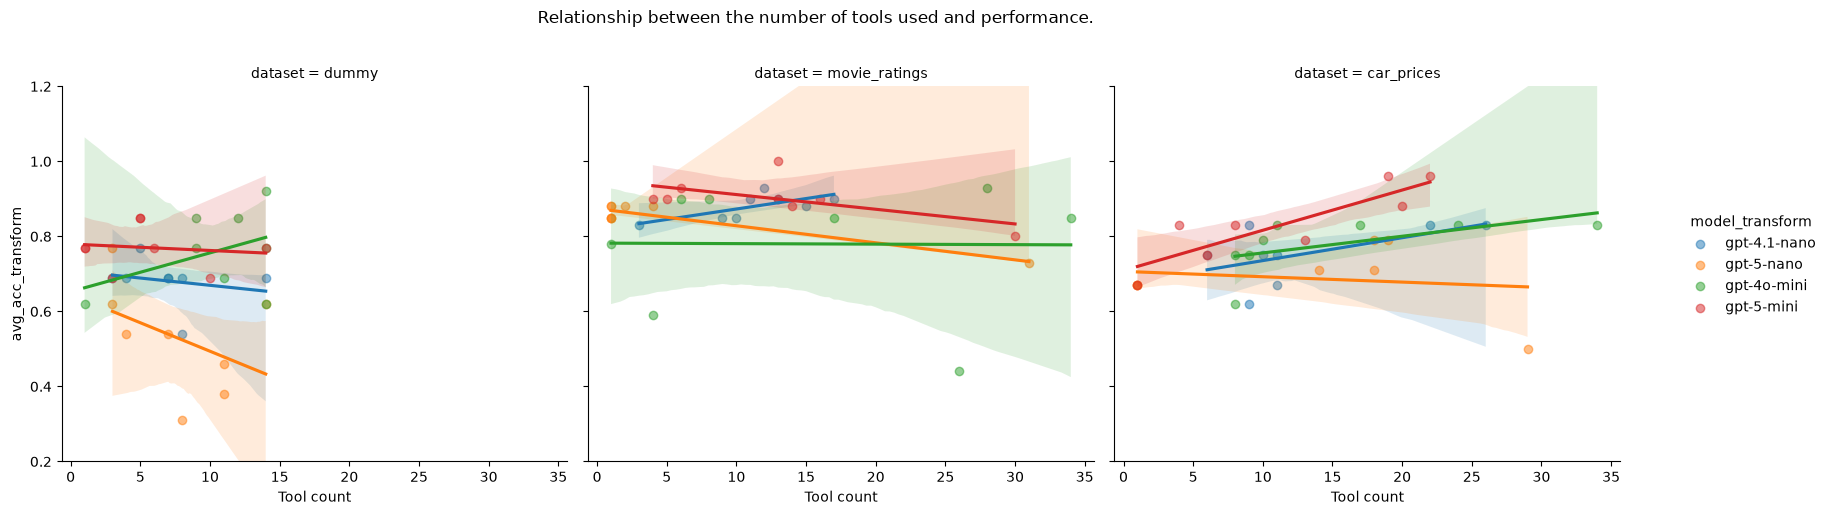

In [31]:
fig = sns.lmplot(data=tool_usage_results, x='Tool count', y='avg_acc_transform', col='dataset', hue='model_transform', scatter_kws={'alpha':0.5})
fig.set(ylim=(0.2, 1.2))
fig.legend.set_bbox_to_anchor((1.02, 0.5))
fig.legend.set_loc("center left")

fig.figure.suptitle("Relationship between the number of tools used and performance.", y=1.02)
plt.tight_layout()
plt.show()
plt.close()

The graphs above show that the overall relationship between the number of tools called and performance is not consistent across models and datasets. In all datasets, there are models that both improve and worsen performance as they use more tools. Not only that, a model that may have a positive relationship between these two variables in one dataset may have the opposite relationship in another. For example, a positive relationship is observed for the *gpt-5-mini* model in the *car_prices* dataset but a negative one in the *movie_ratings* dataset. **Of course, since the number of observations is small, if we had a larger sample, we might observe more consistent data.**

#### Question 2: Is the performance of the transformation agent related to the greater success rate of tool usage?

We saw in the analysis of the previous question that the relationship between the number of tools called and performance is, in general, inconsistent. However, a tool is not always successfully used by an agent. An example of such incorrect usage is when the model calls a tool that should transform a column that does not exist in the current dataframe. Therefore, let's see what the relationship is between the number of successfully called tools and the agent's performance.

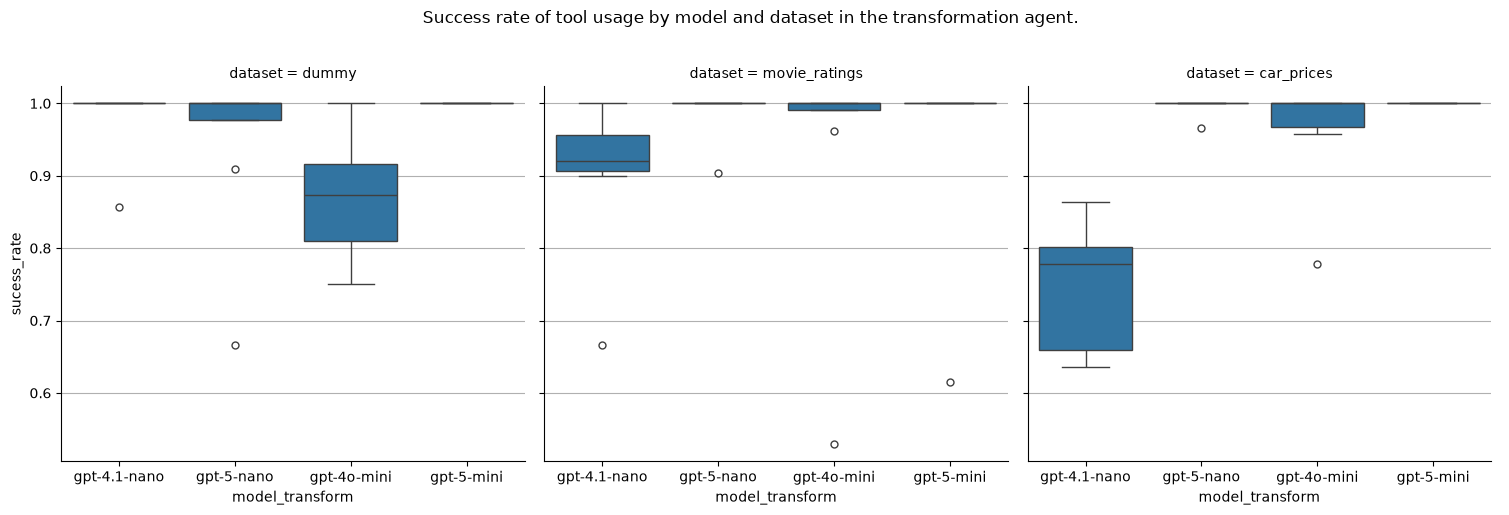

In [32]:
tool_usage_results['sucess_rate'] = tool_usage_results['sucess'] / tool_usage_results['Tool count']
fig = sns.catplot(data=tool_usage_results, y='sucess_rate', x='model_transform', col='dataset', kind='box')

for ax in fig.axes.flat:
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)

fig.figure.suptitle("Success rate of tool usage by model and dataset in the transformation agent.", y=1.02)
plt.tight_layout()
plt.show()
plt.close()

The graphs above show that the models have success rates above 80%, with only the *gpt-4.1-nano* model experiencing difficulties in the *car_prices* dataset. The *gpt-5-mini* and *gpt-5-nano* models maintain success rates almost always at 100%, with some outliers. This demonstrates that they are effective models in what they do.

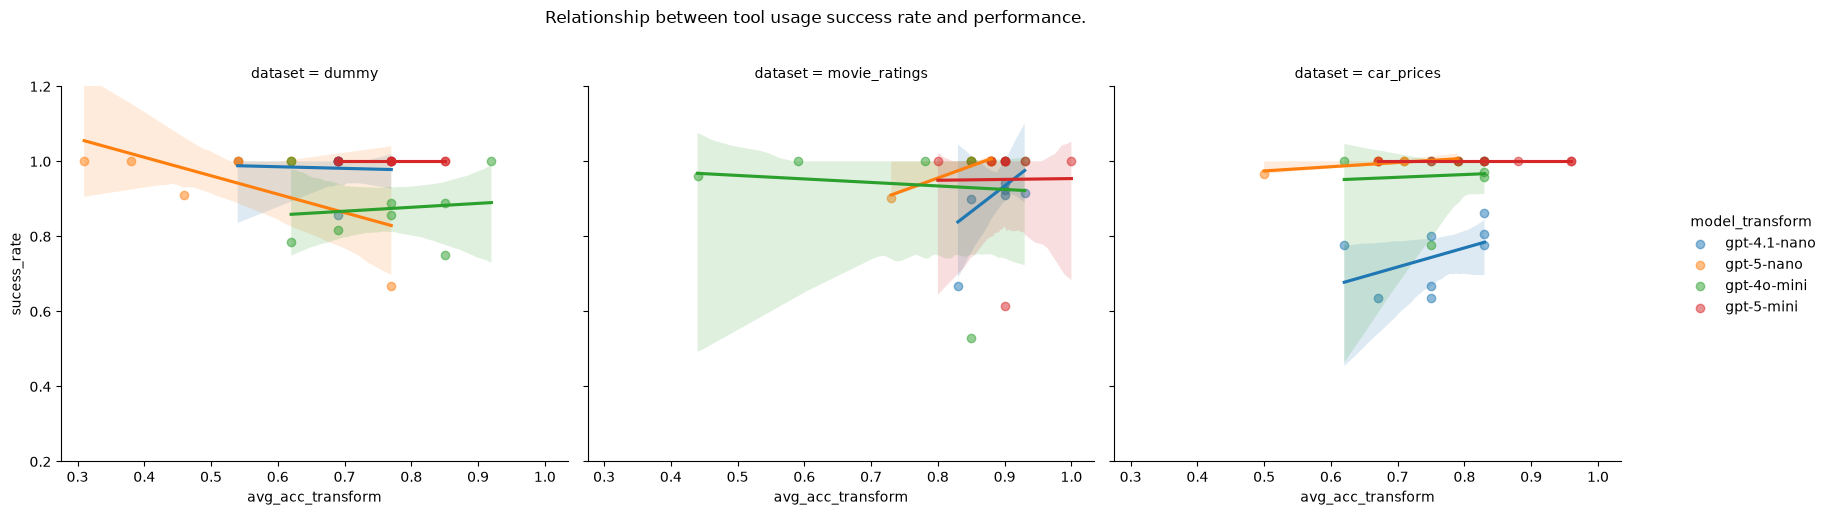

In [33]:
fig = sns.lmplot(data=tool_usage_results, y='sucess_rate', x='avg_acc_transform', col='dataset', hue='model_transform', 
                 scatter_kws={'alpha':0.5})
fig.set(ylim=(0.2, 1.2))
fig.legend.set_bbox_to_anchor((1.02, 0.5))
fig.legend.set_loc("center left")

fig.figure.suptitle("Relationship between tool usage success rate and performance.", y=1.02)
plt.tight_layout()
plt.show()
plt.close()

The graphs above show that the observed relationship between the success rate of tool use and performance is generally positive. The *gpt-5-nano* model in the *dummy* dataset and the *gpt-4o-mini* model in the *movie-ratings* dataset demonstrate an inverse relationship. However, this may also be due to the small sample size.

## 5. Final Thoughts

The design and development of an agentic system must consider its evaluation from the outset. To be able to retrieve usage metrics in all its parts, it is useful to structure the responses of the sub-agents in a way that allows verification of expected results in fixed test cases.

When analyzing the results of applying different models to the evaluation agent, it was considered that the *gpt-5-mini* model presented the best cost-benefit ratio, achieving the best performance rates and the lowest relative costs compared to the other models. In the transformation stage, although *gpt-5-mini* also achieved the best performance, it presented a low relative cost-benefit ratio. When verifying the possibility of maintaining *gpt-5-mini* as the evaluation model but changing to a cheaper model in the transformation (*gpt-4o-mini*), it was observed that this combination presents equivalent performance in 2 of the 3 datasets while decreasing the total cost of system processing. Finally, analyses of tool usage in the transformation phase showed that the success rate is positively related to the overall model performance, even though the total number of tools called has an inconsistent relationship with performance. All analyses are directly affected by the small sample size and, therefore, different conclusions could have been drawn with experiments with more runs.

As future evaluations of other important issues, it is possible to mention:
1) Coverage of tools in the transformation phase regarding the recommendations made by the evaluation agent
2) Checking for meaningless actions that may have been taken in the transformation phase
3) Evaluation of models from other providers such as Google
4) Use of column metadata to assist the evaluation phase
5) Use of initial user directions to improve the evaluation